In [48]:
# -*- coding: utf-8 -*-
"""
Created in 2019
@author: BELLET ALEXANDRE
Guideline followed PEP-0008
"""

import numpy as np
import pandas as pd
from enum import Enum
import time
import os
from skimage.transform import resize 

from tensorflow.keras.preprocessing.image import load_img, img_to_array

class Labels(Enum): # Définition des labels
    ARTIFICIEL = 0
    NATUREL = 1 
    COTE = 2
    FORET = 3
    AUTOROUTE = 4
    VILLE = 5
    MONTAGNE = 6
    OPEN_COUNTRY = 7
    RUE = 8
    GRANDBATIMENT = 9

def get_labels(): # Récupération des labels
    lst = []
    for name,value in Labels.__members__.items():
        lst.append(name)
    return lst

def set_labels(d,col2,col8): # Remplacement des labels numériques par des labels textuels
    data = np.array(d, dtype=object)
    data[data[:,col2]==0,col2] = Labels.ARTIFICIEL.name
    data[data[:,col2]==1,col2] = Labels.NATUREL.name    
    data[data[:,col8]==2,col8] = Labels.COTE.name
    data[data[:,col8]==3,col8] = Labels.FORET.name
    data[data[:,col8]==4,col8] = Labels.AUTOROUTE.name
    data[data[:,col8]==5,col8] = Labels.VILLE.name
    data[data[:,col8]==6,col8] = Labels.MONTAGNE.name
    data[data[:,col8]==7,col8] = Labels.OPEN_COUNTRY.name
    data[data[:,col8]==8,col8] = Labels.RUE.name
    data[data[:,col8]==9,col8] = Labels.GRANDBATIMENT.name
    return pd.DataFrame(data,columns=d.columns)

def unset_labels(d,col2,col8): # Remplacement des labels textuels par des labels numériques
    data = np.array(d, dtype=object)
    data[data[:,col2]=='ARTIFICIEL',col2] = Labels.ARTIFICIEL.value
    data[data[:,col2]=='NATUREL',col2] = Labels.NATUREL.value    
    data[data[:,col8]=='COTE',col8] = Labels.COTE.value
    data[data[:,col8]=='FORET',col8] = Labels.FORET.value
    data[data[:,col8]=='AUTOROUTE',col8] = Labels.AUTOROUTE.value
    data[data[:,col8]=='VILLE',col8] = Labels.VILLE.value
    data[data[:,col8]=='MONTAGNE',col8] = Labels.MONTAGNE.value
    data[data[:,col8]=='OPEN_COUNTRY',col8] = Labels.OPEN_COUNTRY.value
    data[data[:,col8]=='RUE',col8] = Labels.RUE.value
    data[data[:,col8]=='GRANDBATIMENT',col8] = Labels.GRANDBATIMENT.value
    return pd.DataFrame(data,columns=d.columns)

record_time = np.zeros((10,1)) # Tableau pour enregistrer les temps de calcul
def start_time(index):
    record_time[index] = time.time()
    
def stop_time(index): # Retourne le temps écoulé depuis l'appel de start_time avec le même index
    record_time[index] = time.time() - record_time[index]
    return str(float(record_time[index]))[0:7]

def shake_database(path): # Mélange les lignes d'une base de données CSV
    database = pd.read_csv(path)
    database = database.sample(frac=1)
    database.to_csv(path,index=False)
    
def show_database(data,col2,col8): # Affiche le nombre d'éléments par classe dans la base de données
    data = np.array(data)
    print("Contenu Total: "+str(len(data)))
    print("Classée Artificielle: "+str(len(data[data[:,col2]==Labels.ARTIFICIEL.name,col2])))
    print("Classée Naturelle: "+str(len(data[data[:,col2]==Labels.NATUREL.name])))
    print("Classée Côte: "+str(len(data[data[:,col8]==Labels.COTE.name])))
    print("Classée Forêt: "+str(len(data[data[:,col8]==Labels.FORET.name])))
    print("Classée Autoroute: "+str(len(data[data[:,col8]==Labels.AUTOROUTE.name])))
    print("Classée Ville: "+str(len(data[data[:,col8]==Labels.VILLE.name])))
    print("Classée Montagne: "+str(len(data[data[:,col8]==Labels.MONTAGNE.name])))
    print("Classée Paysage Ouvert: "+str(len(data[data[:,col8]==Labels.OPEN_COUNTRY.name])))
    print("Classée Rue: "+str(len(data[data[:,col8]==Labels.RUE.name])))
    print("Classée Grand Batiment: "+str(len(data[data[:,col8]==Labels.GRANDBATIMENT.name])))
    print(" ")
    X=[len(data[data[:,col2]==Labels.ARTIFICIEL.name,col2]), len(data[data[:,col2]==Labels.NATUREL.name])]
    Y=[len(data[data[:,col8]==Labels.COTE.name]),len(data[data[:,col8]==Labels.FORET.name]),len(data[data[:,col8]==Labels.AUTOROUTE.name]),len(data[data[:,col8]==Labels.VILLE.name]),len(data[data[:,col8]==Labels.MONTAGNE.name]),len(data[data[:,col8]==Labels.OPEN_COUNTRY.name]),len(data[data[:,col8]==Labels.RUE.name]),len(data[data[:,col8]==Labels.GRANDBATIMENT.name])]
    
    return X,Y

def lire_images(root_dir, path_cvs ,num, sous_ech=2): # Lecture des images et des classes
    T=[]
    C1=np.zeros(num+1)
    C2=np.zeros(num+1)
    print('Lecture base')
    for i in np.arange(0,num):
        n_Im, classe1, classe2, gabor =lire_database(path_cvs,i)
        img_name = os.path.join(root_dir,str(n_Im)+".jpg")
        I=img_to_array(load_img(img_name))
        I=resize(I,(I.shape[0] // sous_ech, I.shape[1] // sous_ech),anti_aliasing=True)
        T.append(I)
        if classe1=='ARTIFICIEL':
            C1[i]=0
        else:
            C1[i]=1
            
        if classe2 == 'COTE':
            C2[i]=2
        elif classe2 == 'FORET':
            C2[i]=3
        elif classe2 == 'AUTOROUTE':
            C2[i]=4
        elif classe2 == 'VILLE':
            C2[i]=5
        elif classe2 == 'MONTAGNE':
            C2[i]=6
        elif classe2 == 'OPEN_COUNTRY':
            C2[i]=7
        elif classe2 == 'RUE':
            C2[i]=8
        elif classe2 == 'GRANDBATIMENT':
            C2[i]=9
    print('Fin Lecture base')
    return T,C1,C2



def lire_database(path,num): # Lecture d'une ligne de la base de données CSV
    database = pd.read_csv(path)
    #on récupère le nuero d'image et les classes pour la valeur num de la base
    n_Im=database.iloc[num,0]
    classe1=database.iloc[num,1]
    classe2=database.iloc[num,2]
    gabor=database.iloc[num,3:]
    
    return n_Im,classe1,classe2,gabor

def lire_images_et_carac(root_dir, path_cvs ,num, sous_ech=2): # Lecture des images, des classes et des caractéristiques Gabor
    T=[]
    Gab=[]
    C1=np.zeros(num)
    C2=np.zeros(num)
    for i in np.arange(0,num):
        n_Im, classe1, classe2, gabor =lire_database(path_cvs,i)
        img_name = os.path.join(root_dir,str(n_Im)+".jpg")
        I=img_to_array(load_img(img_name))
        I=resize(I,(I.shape[0] // sous_ech, I.shape[1] // sous_ech),anti_aliasing=True)
        T.append(I)
        Gab.append(gabor)
        if classe1=='ARTIFICIEL':
            C1[i]=0
        else:
            C1[i]=1
            
        if classe2 == 'COTE':
            C2[i]=2
        elif classe2 == 'FORET':
            C2[i]=3
        elif classe2 == 'AUTOROUTE':
            C2[i]=4
        elif classe2 == 'VILLE':
            C2[i]=5
        elif classe2 == 'MONTAGNE':
            C2[i]=6
        elif classe2 == 'OPEN_COUNTRY':
            C2[i]=7
        elif classe2 == 'RUE':
            C2[i]=8
        elif classe2 == 'GRANDBATIMENT':
            C2[i]=9

    return T,C1,C2,Gab

# Première partie : Machine learning classique

In [121]:
from sklearn.model_selection import train_test_split

# je récupère uniquement les caractéristiques pour l’ACP, ALD, SVM, MLP
features = donnee.columns[3:] # sélection des colonnes de caractéristiques
X = donnee[features].values # extraction des caractéristiques

# je récupère les labels numériques
y = unset_labels(donnee, 1, 2).iloc[:, 2].astype(int).values

# affichage du contenu de la base
show_database(donnee, 1, 2)

# Découpage (80% apprentissage / 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



Contenu Total: 2688
Classée Artificielle: 1216
Classée Naturelle: 1472
Classée Côte: 360
Classée Forêt: 328
Classée Autoroute: 260
Classée Ville: 308
Classée Montagne: 374
Classée Paysage Ouvert: 410
Classée Rue: 292
Classée Grand Batiment: 356
 


In [102]:
# contrer et reduire les données
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # instanciation de l'objet StandardScaler
X_test_scaled = scaler.fit_transform(X_test) # retourne un tableau numpy contenant les données centrées réduites

X_train = scaler.fit_transform(X_train) # retourne un tableau numpy contenant les données centrées réduites
X_test = scaler.transform(X_test) # utilise les memes parametres que pour l'apprentissage

Variance expliquée cumulée : [0.35559696 0.4573434  0.54819918 0.62138601 0.68402597 0.74464438
 0.78176818 0.81696266 0.84354215 0.86709427 0.88571849 0.90294142
 0.91848118 0.93097371 0.94197691 0.95164949]
Pour expliquer 95.0% de la variance, il faut 16 composantes principales.


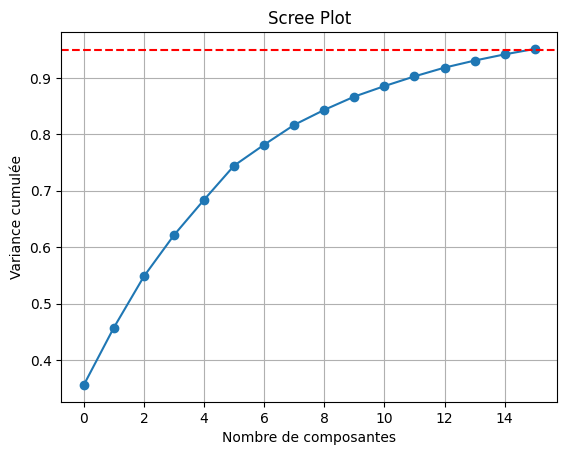

In [106]:
# Visualisation des données de test avec ACP

pca = PCA(n_components=16)
X_test_pca = pca.fit_transform(X_test_scaled)

# Variance cumulée
variance_cumulee = np.cumsum(pca.explained_variance_ratio_)

print("Variance expliquée cumulée :", variance_cumulee)

# Choisir un seuil a atteindre pour connaitre le nombre de composantes principales nécessaires
seuil = 0.95

# Trouver le nombre d'axes nécessaires pour atteindre ce seuil
nb_axes = np.argmax(variance_cumulee >= seuil) + 1

print(f"Pour expliquer {seuil*100}% de la variance, il faut {nb_axes} composantes principales.")

plt.plot(variance_cumulee, marker='o')
plt.axhline(0.95, color='r', linestyle='--')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.title("Scree Plot")
plt.grid()
plt.show()

Pour atteindre un seuil de 95 % de variance expliquée, l’ACP nécessite 16 composantes principales. Cela indique que, malgré la dimension initiale relativement élevée des données, leur dimension intrinsèque est beaucoup plus faible. Les variables présentent donc des corrélations importantes, permettant une réduction de dimension tout en conservant la quasi-totalité de l'information.

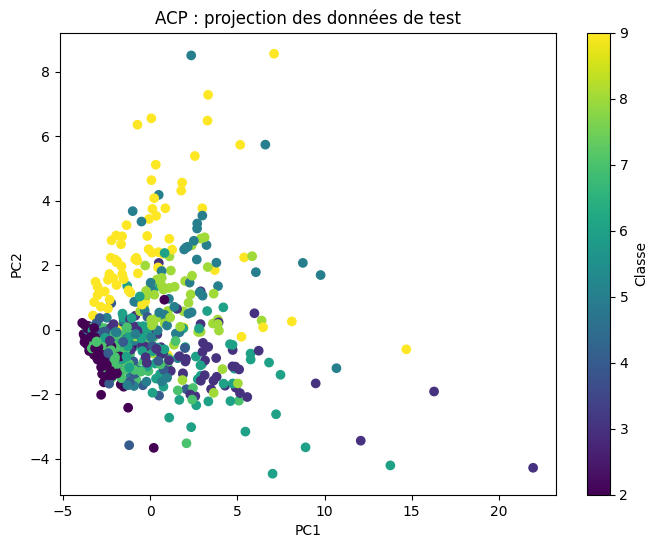

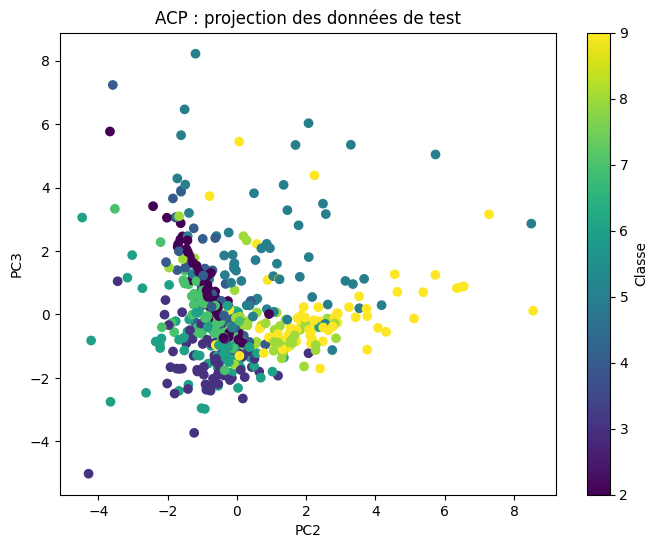

In [107]:

# affichage
plt.figure(figsize=(8, 6))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis')
plt.title("ACP : projection des données de test")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Classe')
plt.show()

# affichage
plt.figure(figsize=(8, 6))
plt.scatter(X_test_pca[:, 1], X_test_pca[:, 2], c=y_test, cmap='viridis')
plt.title("ACP : projection des données de test")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label='Classe')
plt.show()

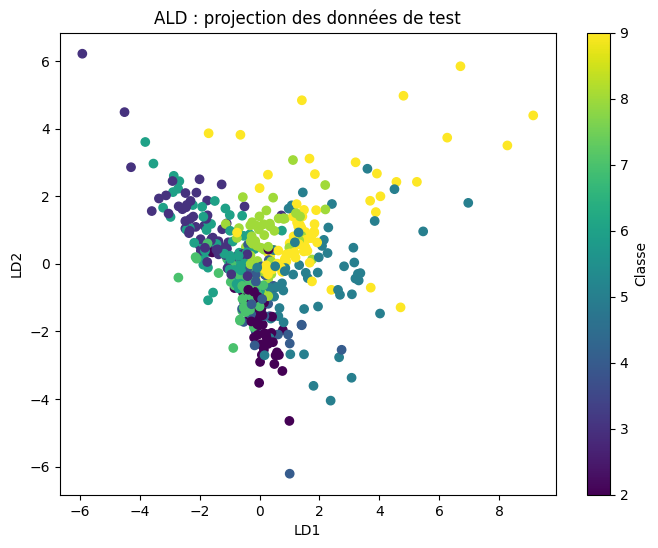

Variance expliquée par chaque axe discriminant :
[0.47454623 0.27852352]

Variance cumulée : 0.7530697545383331

Coefficients discriminants des variables :
            LD1       LD2
Var1   0.366386  0.144384
Var2  -0.087701  0.001832
Var3   0.386326  0.172079
Var4   0.658372  0.342432
Var5   0.089343  0.126535
Var6   0.022483  0.015884
Var7  -0.256778  0.055425
Var8  -0.137138  0.046314
Var9  -0.086913  0.090064
Var10 -0.106959  0.011958
Var11  0.179016  0.006184
Var12 -0.387528  0.217415
Var13 -0.001206 -0.400463
Var14  0.031073 -0.323648
Var15  0.301243 -0.090622
Var16  0.210864 -0.128858
Var17 -0.100541  0.035072
Var18 -0.171018  0.040412
Var19  0.165867  0.143066
Var20 -0.136574  0.053523
Var21  0.132671  0.144355
Var22  0.200531  0.020832
Var23 -0.143642 -0.002016
Var24 -0.462356  0.147156
Var25 -0.085718  0.002709
Var26 -0.037464  0.015336
Var27 -0.048798 -0.033763


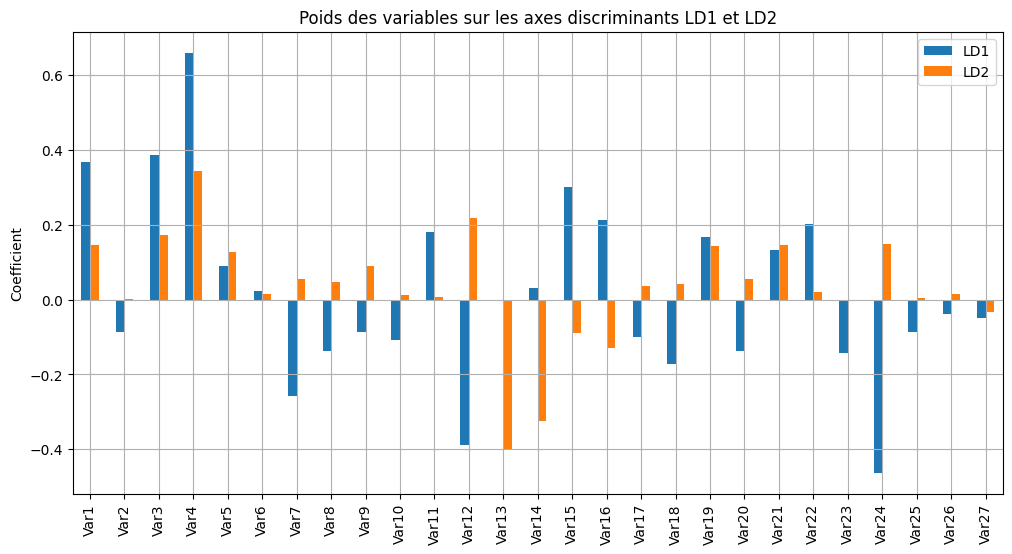

In [117]:

# Visualisation des données de test avec ALD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis



lda = LinearDiscriminantAnalysis(n_components=2)
X_test_lda = lda.fit(X_train, y_train).transform(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(X_test_lda[:, 0], X_test_lda[:, 1], c=y_test, cmap='viridis')
plt.title("ALD : projection des données de test")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.colorbar(label='Classe')
plt.show()

print("Variance expliquée par chaque axe discriminant :")
print(lda.explained_variance_ratio_)

print("\nVariance cumulée :",
      np.sum(lda.explained_variance_ratio_))

# Matrice des poids (LOADINGS)
coeffs = pd.DataFrame(
    lda.scalings_[:, :2],
    index=[f"Var{i+1}" for i in range(X_train.shape[1])],
    columns=["LD1", "LD2"]
)

print("\nCoefficients discriminants des variables :")
print(coeffs)

# -------------------------------------------------
# 7. VISUALISATION DU POIDS DES VARIABLES SUR LD1 ET LD2
# -------------------------------------------------
coeffs.plot(kind="bar", figsize=(12, 6))
plt.title("Poids des variables sur les axes discriminants LD1 et LD2")
plt.ylabel("Coefficient")
plt.grid()
plt.show()



Les variables avec un grand coefficient (positif ou négatif) sont celles qui séparent le mieux les classes. Les variables proches de 0 contribuent peu à la discrimination (moins importantes dans l’ALD).

In [118]:
coeffs["Importance_LD1"] = coeffs["LD1"].abs()
coeffs["Importance_LD2"] = coeffs["LD2"].abs()

print(coeffs.sort_values("Importance_LD1", ascending=False).head())


            LD1       LD2  Importance_LD1  Importance_LD2
Var4   0.658372  0.342432        0.658372        0.342432
Var24 -0.462356  0.147156        0.462356        0.147156
Var12 -0.387528  0.217415        0.387528        0.217415
Var3   0.386326  0.172079        0.386326        0.172079
Var1   0.366386  0.144384        0.366386        0.144384


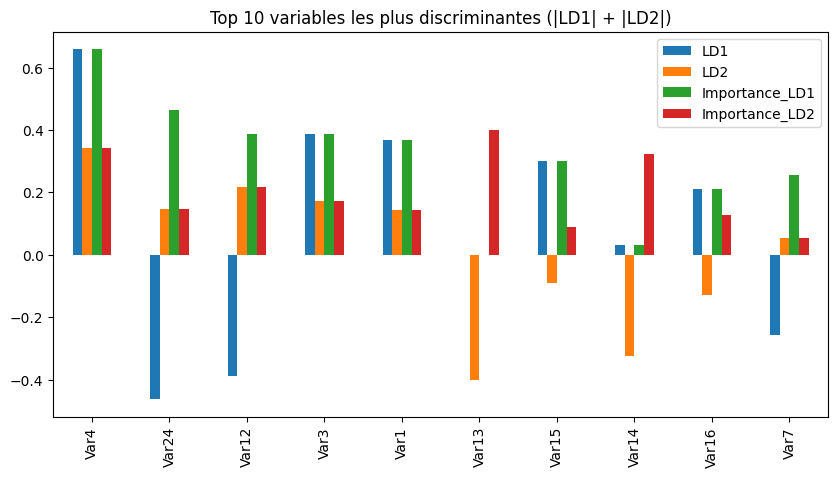

In [119]:
top = coeffs.abs().sum(axis=1).sort_values(ascending=False).head(10)
coeffs.loc[top.index].plot(kind="bar", figsize=(10,5))
plt.title("Top 10 variables les plus discriminantes (|LD1| + |LD2|)")
plt.show()


In [120]:
# Choix optimal du MLP avec validation croisée

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate

neurones = [10, 20, 50, 100]
activations = ['relu', 'tanh', 'logistic']

best_score_mlp = 0
best_params_mlp = None

for h in neurones:
    for act in activations:
        mlp = MLPClassifier(hidden_layer_sizes=(h,), activation=act, max_iter=800)

        scores = cross_validate(
            mlp, X_train, y_train,
            cv=5,
            scoring='accuracy',
            return_estimator=False
        )

        score = np.mean(scores['test_score'])

        print(f"MLP (h={h}, act={act}) → {score:.4f}")

        if score > best_score_mlp:
            best_score_mlp = score
            best_params_mlp = (h, act)

print("\nMeilleur MLP :", best_params_mlp, ", score =", best_score_mlp)


c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached 

MLP (h=10, act=relu) → 0.7065


c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached 

MLP (h=10, act=tanh) → 0.7107


c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached 

...

c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached 

MLP (h=100, act=tanh) → 0.7023


c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached 

MLP (h=100, act=logistic) → 0.7274

Meilleur MLP : (50, 'logistic') , score = 0.7288372093023255


c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


In [122]:
# Choix optimal du SVM avec validation croisée

from sklearn.svm import SVC

kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]

best_score_svm = 0
best_params_svm = None

for k in kernels:
    for C in C_values:
        svm = SVC(kernel=k, C=C)

        scores = cross_validate(
            svm, X_train, y_train,
            cv=5,
            scoring='accuracy'
        )

        score = np.mean(scores['test_score'])
        print(f"SVM (kernel={k}, C={C}) → {score:.4f}")

        if score > best_score_svm:
            best_score_svm = score
            best_params_svm = (k, C)

print("\nMeilleur SVM :", best_params_svm, ", score =", best_score_svm)


SVM (kernel=linear, C=0.1) → 0.6772
SVM (kernel=linear, C=1) → 0.7000
SVM (kernel=linear, C=10) → 0.7074
SVM (kernel=rbf, C=0.1) → 0.5530
SVM (kernel=rbf, C=1) → 0.6777
SVM (kernel=rbf, C=10) → 0.7070
SVM (kernel=poly, C=0.1) → 0.2902
SVM (kernel=poly, C=1) → 0.5033
SVM (kernel=poly, C=10) → 0.6414

Meilleur SVM : ('linear', 10) , score = 0.7074418604651163


In [123]:
# Évaluation finale sur la base de test + intervalles de confiance

# MLP
h, act = best_params_mlp
mlp_best = MLPClassifier(hidden_layer_sizes=(h,), activation=act, max_iter=800)
mlp_best.fit(X_train, y_train)
y_pred_mlp = mlp_best.predict(X_test)


# SVM
k, C = best_params_svm
svm_best = SVC(kernel=k, C=C)
svm_best.fit(X_train, y_train)
y_pred_svm = svm_best.predict(X_test)

c:\Users\Etudiant\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


In [124]:
# Métriques + intervalle de confiance

from sklearn.metrics import accuracy_score
import scipy.stats as st

def intervalle_confiance(pred, true):
    acc = accuracy_score(true, pred)
    n = len(true)
    se = np.sqrt(acc * (1 - acc) / n)
    ic = st.norm.interval(0.95, loc=acc, scale=se)
    return acc, ic

acc_mlp, ic_mlp = intervalle_confiance(y_pred_mlp, y_test)
acc_svm, ic_svm = intervalle_confiance(y_pred_svm, y_test)

print("MLP → accuracy =", acc_mlp, "IC95=", ic_mlp)
print("SVM → accuracy =", acc_svm, "IC95=", ic_svm)


MLP → accuracy = 0.7434944237918215 IC95= (np.float64(0.7065929071092324), np.float64(0.7803959404744106))
SVM → accuracy = 0.7323420074349443 IC95= (np.float64(0.6949306010672749), np.float64(0.7697534138026136))


Refaire le modele avec 20%, 40%, 60%, 80% apprentissage puis en suprimant les composantes Y, Cb, Cr en faisant --- X_reduit = donnee[features[:-3]].values --- et comparer les classifieurs SVM et MLP et voir si la dependance des deux classifieur à la couleur 

# Deuxième partie : Deep learning
